## Flanking versus breaching

- Definitions (Nichols et al., 2023): Flanking = lateral scour around the berm end; breaching = perpendicular break through the berm.

- Soil-texture pattern (Results 3.1, Table 1): Flanking was more common than breaching overall. On loamy sand, 47% of berms flanked vs. 9% breached; on clay loam, 31% flanked vs. 17% breached. Coarser soils skew toward flanking; finer soils have a higher breach share.
- Vegetation effect (abstract): Where breaches occurred on coarser textured soils, up- and downslope differences in grass cover diminished.

- Interpretation (not from the paper): Sandy/loamy sand has low cohesion, so once water routes around a berm end it can incise a scour pathway quickly → more flanking. Clay loam resists end-scour, so water is more likely to pond and overtop → more breaching. [Note: Nichols et al. do not discuss this mechanism; their discussion centers on moisture-holding capacity and vegetation response.]


 Reference

- Nichols, M. H., Duke, S. E., Holifield Collins, C., & Thompson, L. (2023). Legacy earthen berms influence vegetation and hydrologic complexity in the Altar Valley, Arizona. *International Soil and Water Conservation Research*. https://doi.org/10.1016/j.iswcr.2023.01.005


**Failure Mechanism Analysis — Summary of Results**

Strongest predictors of whether failed berms breach vs. flank

- Berm length is the strongest categorical predictor (χ² = 46.8, p = 6.8 × 10⁻¹¹, Cramér's V = 0.246). Long berms (> 50 m) are nearly twice as likely to breach as short berms (Fisher OR = 1.95, p = 0.019): 40% of failed long berms breached vs. 26% of failed short berms.

Log flow accumulation is the strongest continuous predictor (KW H = 42.9, p = 4.9 × 10⁻¹⁰), and berm angle is also highly significant (KW H = 29.0, p = 5.1 × 10⁻⁷). Higher contributing areas and berm alignment both distinguish breach from flank outcomes.

All significant categorical predictors (ranked by effect size)

Predictor	χ²	p	Cramér's V

Berm length	46.8	6.8e-11	0.246

Texture (top 3)	30.8	3.3e-06	0.156

High Clay	18.5	9.7e-05	0.154

Slope	13.8	0.0010	0.133

Soil Development	13.8	0.0010	0.133

Landform	14.4	0.0061	0.096

Non-significant predictors

SAVI vegetation indices showed no relationship with failure type — downstream (p = 0.38), upstream (p = 0.88), and vegetation effect (p = 0.91) were all non-significant. Failure mode does not predict vegetation response differences.

Key directional findings (conditional probabilities)

Among failed berms only:

Sandy loam → 75% flank, 25% breach; clay loam → 51% flank, 49% breach (clay increases breach risk)

Fan terraces → 75% flank, 25% breach; flood plains → 56% flank, 44% breach

Steep slopes (> 2%) → 71% flank; shallow slopes → 55% flank (steeper → more flanking)

B-horizon soils → 74% flank; no B horizon → 57% flank (more developed soils → more flanking)

High clay → more breaching, less flanking (V = 0.154)

Interaction effects

Within-landform Texture × Fail_Type interaction was testable only for flood plains (χ² p = 0.012), confirming that the texture–failure relationship holds within that landform. Fan terraces and stream terraces had insufficient cell counts for stratified analysis.

Interpretation

Breaching is associated with longer berms, finer-textured (clay-rich) soils, higher flow accumulation, shallower slopes, flood-plain settings, and less-developed soil profiles — consistent with concentrated overtopping where water volume and soil erodibility are high. Flanking is associated with shorter berms, sandy soils, steep slopes, fan terraces, and B-horizon soils — consistent with end-run failures where flow diverts around the structure. Vegetation (SAVI) shows no differential effect by failure type.

In [38]:
import pandas as pd
import glob
import numpy as np
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact, chi2_contingency

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module=r"seaborn(\..*)?")

# Global display preferences (apply notebook-wide)
from IPython.display import display, HTML
pd.set_option("display.max_columns", 50)


In [39]:
import sys as _sys
_sys.path.insert(0, '../src')
from constants import (
    INTACT_COL, DEGRADED_COL, BREACH_COL, FLANK_COL,
    LF_COLORS, lf_order,
    LENGTH_COLORS, length_order,
    SLOPE_COLORS, slope_order,
    CLAY_COLORS, clay_order,
    SOILDEV_COLORS, soildev_order,
    TEXTURE_COLORS, texture_order,
    LBL_EFFECTIVE, LBL_INEFFECTIVE, eff_order, eff_colors,
    fail_order, fail_colors,
    MODEL_CLR_CONDITION, MODEL_CLR_VEGRESPONSE, MODEL_CLR_CHANCE,
)


In [40]:
data = pd.read_csv('../data/merged.csv')
print(f'Loaded {len(data):,} rows  |  columns: {list(data.columns)}')


Loaded 775 rows  |  columns: ['system:index', 'AREASYMBOL', 'FA_30_max', 'FA_30_mean', 'FA_60_max', 'FA_60_mean', 'Fail_Type', 'MUKEY', 'MUSYM', 'Note', 'Notes', 'Shape_Leng', 'Structure_', 'Type', 'aspectD_60', 'aspectU_60', 'berm_angle', 'berm_elev', 'channel_1000m', 'channel_100m', 'channel_10m', 'channel_200m', 'channel_500m', 'channel_700m', 'compare', 'convD_60', 'convU_60', 'id', 'landform', 'latitude', 'longitude', 'other_dist', 'other_elev', 'road_dist', 'saviD_60', 'saviU_60', 'savi_background', 'slopeD_100', 'slopeD_200', 'slopeD_60', 'slopeU_100', 'slopeU_200', 'slopeU_60', 'slope_100', 'slope_200', 'surf_clayD_60', 'surf_clayU_60', 'surf_clay_background', 'surf_claybg', 'surf_sandD_60', 'surf_sandU_60', 'surf_sand_background', 'surf_sandbg', 'surfsocD_60', 'surfsocU_60', 'surfsoc_background', 'surfsocbg', 'zD_60', 'zU_60', '.geo', 'MapUnitName', 'SlopeClass', 'Landform', 'ParentMaterial', 'TypicalProfile', 'Texture', 'claytotal_r', 'sandtotal_r', 'silttotal_r', 'Condition'

In [ ]:
# Where does this term come from?
data['berm_angle']

0     -72.029343
1     -41.091470
2      79.006820
3     -74.491529
4      -3.966655
         ...    
770   -61.471091
771   -14.077517
772     4.514847
773    16.896728
774     8.200288
Name: berm_angle, Length: 775, dtype: float64

In [37]:
# ── Additional shared-module imports ──────────────────────────────────────────
from analysis import chi2_with_cramers_v, _bh_adjust
from registry import register_failure_mechanisms_figure
from itertools import combinations as _combinations
from scipy.stats import kruskal as _kruskal, mannwhitneyu as _mannwhitneyu

import os as _os

# ── Data preparation ─────────────────────────────────────────────────────────
df = data.copy()

# Fill missing Fail_Type with "Intact"; drop ambiguous "Breach and Flank"
df['Fail_Type'] = df['Fail_Type'].fillna("Intact")
df = df.loc[df['Fail_Type'] != 'Breach and Flank'].copy()

_fig_dir = _os.path.join('..', 'figures', 'failure_mechanisms')
_os.makedirs(_fig_dir, exist_ok=True)

print(f"Working df: {len(df):,} rows")
print(f"\nFail_Type value counts:")
print(df['Fail_Type'].value_counts().to_string())
print(f"\nOverall proportions:")
print((df['Fail_Type'].value_counts(normalize=True) * 100).round(1).to_string())

# ── Top-3 soil textures by count ─────────────────────────────────────────────
_top3_tex = df['Texture'].value_counts().head(3).index.tolist()
print(f"\nTop 3 textures: {_top3_tex}")

# ── Helper: grouped bar chart for 3-level Fail_Type ─────────────────────────
def _plot_fail_bars(ax, ct, group_order, title, chi2_p=None):
    """Grouped bar chart showing Fail_Type proportions (Intact / Breach / Flank)
    for each level of *group_order*."""
    _pct = ct.div(ct.sum(axis=1), axis=0)
    _x = np.arange(len(group_order))
    _w = 0.25
    for i, ft in enumerate(fail_order):
        vals = [_pct.loc[g, ft] if g in _pct.index else 0 for g in group_order]
        ax.bar(_x + i * _w, vals, _w, label=ft,
               color=fail_colors[ft], edgecolor='black', linewidth=0.6)
    ax.set_xticks(_x + _w)
    ax.set_xticklabels(group_order, rotation=0, ha='center')
    ax.set_ylabel('Proportion')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylim(0, 1)
    _sub = f'\n(p = {chi2_p:.3g})' if chi2_p is not None else ''
    ax.set_title(f'{title}{_sub}')
    ax.legend(frameon=False)

# ── Helper: pairwise chi-square on 2×3 Fail_Type sub-tables ─────────────────
def _pairwise_chi2_3cat(ct, alpha=0.05):
    """Pairwise chi-square between all row pairs of a groups × Fail_Type table.
    Returns DataFrame with FDR-corrected q-values."""
    groups = list(ct.index)
    rows = []
    for a, b in _combinations(groups, 2):
        sub = ct.loc[[a, b]]
        chi2, p, dof, _ = chi2_contingency(sub)
        rows.append({'group_a': a, 'group_b': b, 'chi2': chi2, 'dof': dof, 'p_raw': p})
    _df = pd.DataFrame(rows)
    if len(_df):
        _df['q_fdr'] = _bh_adjust(_df['p_raw'].values)
        _df['significant'] = _df['q_fdr'] < alpha
    return _df

# ── Helper: Kruskal-Wallis + pairwise Mann-Whitney for continuous × Fail_Type ─
def _continuous_by_failtype(df_sub, col, label=None):
    """Kruskal-Wallis across Fail_Type groups + pairwise Mann-Whitney with FDR."""
    label = label or col
    groups = {ft: df_sub.loc[df_sub['Fail_Type'] == ft, col].dropna()
              for ft in fail_order}
    arrays = [groups[ft] for ft in fail_order if len(groups[ft]) > 0]
    if len(arrays) < 2:
        print(f'  {label}: fewer than 2 non-empty groups')
        return None
    _H, _p_kw = _kruskal(*arrays)
    print(f'Kruskal-Wallis  H = {_H:.2f},  p = {_p_kw:.3g}')
    print(f'  Group medians:')
    for ft in fail_order:
        g = groups[ft]
        if len(g):
            print(f'    {ft:8s}: median = {g.median():.3f}  (n = {len(g)})')

    rows = []
    for a, b in _combinations(fail_order, 2):
        if len(groups[a]) == 0 or len(groups[b]) == 0:
            continue
        _U, _p = _mannwhitneyu(groups[a], groups[b], alternative='two-sided')
        rows.append({'group_a': a, 'group_b': b, 'U': _U, 'p_raw': _p})
    pw = pd.DataFrame(rows)
    if len(pw):
        pw['q_fdr'] = _bh_adjust(pw['p_raw'].values)
        pw['significant'] = pw['q_fdr'] < 0.05
    print(f'\nPairwise Mann-Whitney (FDR q < 0.05):')
    _sig = pw[pw['significant']] if len(pw) else pw
    if len(_sig):
        display(_sig.round(4).reset_index(drop=True))
    else:
        print('  (none)')
    return {'H': _H, 'p_kw': _p_kw, 'pairwise': pw, 'groups': groups}

# ── Helper: box + strip plot for continuous × Fail_Type ──────────────────────
def _plot_continuous_by_failtype(ax, df_sub, col, title, ylabel=None):
    """Box + strip plot of *col* by Fail_Type with fail_colors."""
    _palette = {ft: fail_colors[ft] for ft in fail_order}
    sns.boxplot(data=df_sub, x='Fail_Type', y=col, order=fail_order,
                palette=_palette, showfliers=False, ax=ax,
                boxprops=dict(edgecolor='black'), medianprops=dict(color='black'))
    sns.stripplot(data=df_sub, x='Fail_Type', y=col, order=fail_order,
                  palette=_palette, size=3, alpha=0.35, jitter=True, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    if ylabel:
        ax.set_ylabel(ylabel)


Working df: 775 rows

Fail_Type value counts:
Fail_Type
Intact    458
Flank     203
Breach    114

Overall proportions:
Fail_Type
Intact    59.1
Flank     26.2
Breach    14.7

Top 3 textures: ['Clay loam', 'Sandy loam', 'Silt loam']


In [ ]:
# ── Overall Fail_Type distribution by Landform ────────────────────────────────
print("=== Fail_Type counts by Landform ===")
_ct_lf = pd.crosstab(df['Landform'], df['Fail_Type'])[fail_order]
display(_ct_lf)

print("\n=== Within-landform proportions (%) ===")
_ct_lf_pct = (_ct_lf.div(_ct_lf.sum(axis=1), axis=0) * 100).round(1)
display(_ct_lf_pct)

print(f"\nTotal failed (Breach + Flank): "
      f"{(df['Fail_Type'] != 'Intact').sum()} / {len(df)} "
      f"= {(df['Fail_Type'] != 'Intact').mean():.1%}")
      

=== Fail_Type counts by Landform ===


Fail_Type,Intact,Breach,Flank
Landform,,,
Fan terraces,153,31,92
Flood plains,215,64,80
Stream terraces,90,19,31



=== Within-landform proportions (%) ===


Fail_Type,Intact,Breach,Flank
Landform,,,
Fan terraces,55.4,11.2,33.3
Flood plains,59.9,17.8,22.3
Stream terraces,64.3,13.6,22.1



Total failed (Breach + Flank): 317 / 775 = 40.9%


In [6]:
# ── Texture × Fail_Type (top 3 textures): chi-square + pairwise ──────────────
_sub_tex = df.loc[df['Texture'].isin(_top3_tex)].dropna(subset=['Texture', 'Fail_Type']).copy()
print(f"Filtered to top 3 textures: {_top3_tex}  (n = {len(_sub_tex)})")

# Crosstab: counts + within-texture proportions
_ct_tex = pd.crosstab(_sub_tex['Texture'], _sub_tex['Fail_Type'])[fail_order]
print("\n=== Texture × Fail_Type counts ===")
display(_ct_tex)

_ct_tex_pct = (_ct_tex.div(_ct_tex.sum(axis=1), axis=0) * 100).round(1)
print("\n=== Within-texture proportions (%) ===")
display(_ct_tex_pct)

# Global chi-square + Cramér's V
_chi2_tex, _p_tex, _dof_tex, _V_tex, _ = chi2_with_cramers_v(_ct_tex)
print(f"\nχ² = {_chi2_tex:.2f},  p = {_p_tex:.3g},  dof = {_dof_tex},  Cramér's V = {_V_tex:.3f}")

# Pairwise chi-square on 2×3 sub-tables (FDR-corrected)
_pw_tex = _pairwise_chi2_3cat(_ct_tex)
_pw_tex_sig = _pw_tex[_pw_tex['significant']] if len(_pw_tex) else _pw_tex
print(f"\n=== Pairwise chi-square (FDR q < 0.05): {len(_pw_tex_sig)} significant ===")
if len(_pw_tex_sig):
    display(_pw_tex_sig.round(4).reset_index(drop=True))
else:
    print("  (none)")

Filtered to top 3 textures: ['Clay loam', 'Sandy loam', 'Silt loam']  (n = 630)

=== Texture × Fail_Type counts ===


Fail_Type,Intact,Breach,Flank
Texture,,,
Clay loam,175,53,55
Sandy loam,97,28,85
Silt loam,88,19,30



=== Within-texture proportions (%) ===


Fail_Type,Intact,Breach,Flank
Texture,,,
Clay loam,61.8,18.7,19.4
Sandy loam,46.2,13.3,40.5
Silt loam,64.2,13.9,21.9



χ² = 30.82,  p = 3.34e-06,  dof = 4,  Cramér's V = 0.156

=== Pairwise chi-square (FDR q < 0.05): 2 significant ===


,group_a,group_b,chi2,dof,p_raw,q_fdr,significant
0,Clay loam,Sandy loam,26.2791,2,0.0000,0.0000,True
1,Sandy loam,Silt loam,13.7152,2,0.0011,0.0016,True


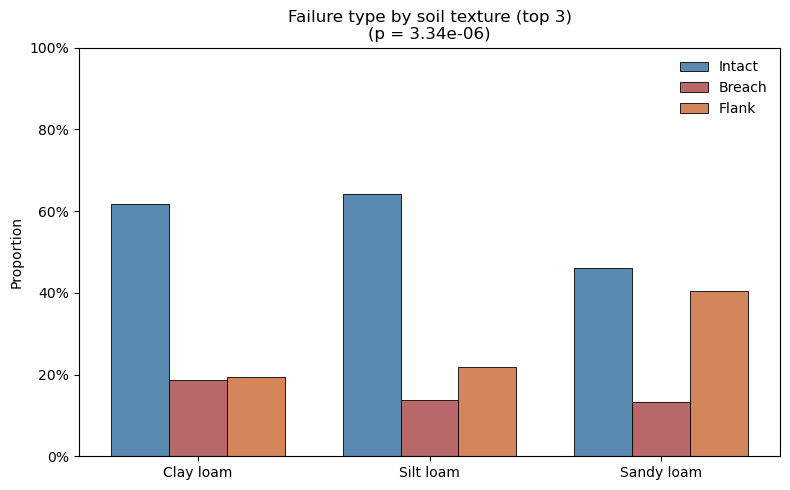

Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 3)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt
Saved: fig_texture_fail_type.png


In [7]:
# ── Texture × Fail_Type figure (top 3 textures, 3-category) ──────────────────
_tex3_order = [t for t in texture_order if t in _top3_tex]
_fig_tex, _ax_tex = plt.subplots(figsize=(8, 5))
_plot_fail_bars(_ax_tex, _ct_tex, _tex3_order,
                title='Failure type by soil texture (top 3)',
                chi2_p=_p_tex)
plt.tight_layout()
plt.show()

# Save + register
_fname_tex = 'fig_texture_fail_type.png'
_fig_tex.savefig(_os.path.join(_fig_dir, _fname_tex), dpi=300, bbox_inches='tight')

register_failure_mechanisms_figure(
    'fig3', _fname_tex,
    f'Top-3 texture × failure type (Intact / Breach / Flank). '
    f'χ² = {_chi2_tex:.2f}, p = {_p_tex:.3g}, '
    f"Cramér's V = {_V_tex:.3f}. {len(_pw_tex_sig)} significant pairwise contrasts.",
    f'Three-category failure breakdown across top textures. '
    f'Sandy loam shows highest flanking; clay loam has highest breach share.',
)
print(f'Saved: {_fname_tex}')

## Landform × Fail_Type

In [8]:
# ── Landform × Fail_Type: chi-square + pairwise (3-category) ─────────────────
_sub_lf = df.dropna(subset=['Landform', 'Fail_Type']).copy()

_ct_lf2 = pd.crosstab(_sub_lf['Landform'], _sub_lf['Fail_Type'])[fail_order]
print("=== Landform × Fail_Type counts ===")
display(_ct_lf2)

_ct_lf2_pct = (_ct_lf2.div(_ct_lf2.sum(axis=1), axis=0) * 100).round(1)
print("\n=== Within-landform proportions (%) ===")
display(_ct_lf2_pct)

_chi2_lf, _p_lf, _dof_lf, _V_lf, _ = chi2_with_cramers_v(_ct_lf2)
print(f"\nχ² = {_chi2_lf:.2f},  p = {_p_lf:.3g},  dof = {_dof_lf},  Cramér's V = {_V_lf:.3f}")

_pw_lf = _pairwise_chi2_3cat(_ct_lf2)
_pw_lf_sig = _pw_lf[_pw_lf['significant']] if len(_pw_lf) else _pw_lf
print(f"\n=== Pairwise chi-square (FDR q < 0.05): {len(_pw_lf_sig)} significant ===")
if len(_pw_lf_sig):
    display(_pw_lf_sig.round(4).reset_index(drop=True))
else:
    print("  (none)")

=== Landform × Fail_Type counts ===


Fail_Type,Intact,Breach,Flank
Landform,,,
Fan terraces,153,31,92
Flood plains,215,64,80
Stream terraces,90,19,31



=== Within-landform proportions (%) ===


Fail_Type,Intact,Breach,Flank
Landform,,,
Fan terraces,55.4,11.2,33.3
Flood plains,59.9,17.8,22.3
Stream terraces,64.3,13.6,22.1



χ² = 14.41,  p = 0.00609,  dof = 4,  Cramér's V = 0.096

=== Pairwise chi-square (FDR q < 0.05): 1 significant ===


,group_a,group_b,chi2,dof,p_raw,q_fdr,significant
0,Fan terraces,Flood plains,12.104,2,0.0024,0.0071,True


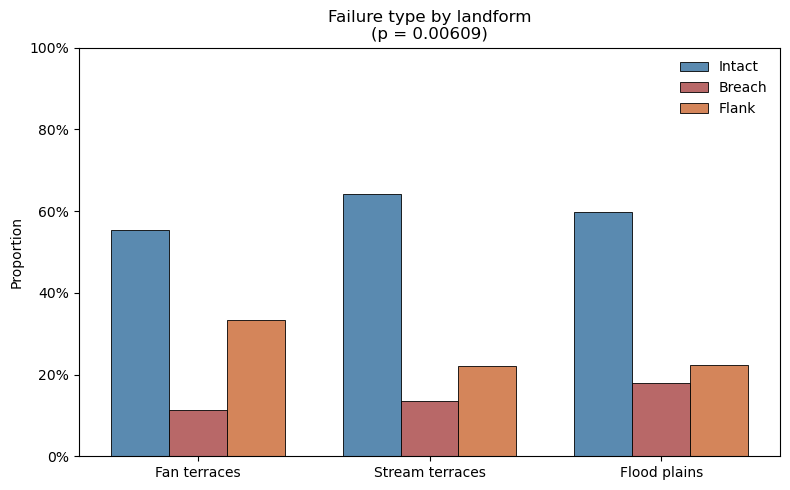

Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 4)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt
Saved: fig_landform_fail_type.png


In [9]:
# ── Landform × Fail_Type figure (3-category) ─────────────────────────────────
_fig_lf, _ax_lf = plt.subplots(figsize=(8, 5))
_plot_fail_bars(_ax_lf, _ct_lf2, lf_order,
                title='Failure type by landform',
                chi2_p=_p_lf)
plt.tight_layout()
plt.show()

_fname_lf = 'fig_landform_fail_type.png'
_fig_lf.savefig(_os.path.join(_fig_dir, _fname_lf), dpi=300, bbox_inches='tight')

register_failure_mechanisms_figure(
    'fig4', _fname_lf,
    f'Landform × failure type (Intact / Breach / Flank). '
    f'χ² = {_chi2_lf:.2f}, p = {_p_lf:.3g}, '
    f"Cramér's V = {_V_lf:.3f}. {len(_pw_lf_sig)} significant pairwise contrasts.",
    f'Failure mode breakdown across landforms. '
    f'Fan terraces show highest flanking rate; flood plains highest breach rate.',
)
print(f'Saved: {_fname_lf}')

## Length × Fail_Type

Berm length has been hypothesised to influence failure mode. Longer berms may
concentrate more runoff and be more prone to **breaching**, while shorter berms
may be more susceptible to **flanking** from flow diversion around the ends.

In [10]:
# ── Length × Fail_Type: probability table + Fisher tests ──────────────────────
_sub_len = df.dropna(subset=['Berm_Length_Class', 'Fail_Type']).copy()

# Crosstab counts & within-length proportions
_ct_len = pd.crosstab(_sub_len['Berm_Length_Class'], _sub_len['Fail_Type'])[fail_order]
print('─── counts ───')
print(_ct_len)
print()

_pct_len = _ct_len.div(_ct_len.sum(axis=1), axis=0).mul(100).round(1)
print('─── within-length-class % ───')
print(_pct_len)
print()

# Global chi-square test
_chi2_len, _p_len, _dof_len, _V_len, _ = chi2_with_cramers_v(_ct_len)
print(f'χ²({_dof_len}) = {_chi2_len:.2f},  p = {_p_len:.3g},  Cramér\'s V = {_V_len:.3f}')
print()

# ── Unconditional & conditional probabilities ─────────────────────────────────
_rows = []
for _lbl in length_order:
    _g = _sub_len.loc[_sub_len['Berm_Length_Class'] == _lbl, 'Fail_Type']
    _n = len(_g)
    _n_intact  = (_g == 'Intact').sum()
    _n_breach  = (_g == 'Breach').sum()
    _n_flank   = (_g == 'Flank').sum()
    _n_failed  = _n_breach + _n_flank
    _rows.append({
        'Length_Bin': _lbl, 'n': _n,
        'P(Intact)': _n_intact / _n,
        'P(Breach)': _n_breach / _n,
        'P(Flank)':  _n_flank  / _n,
        'P(Breach|failed)': _n_breach / _n_failed if _n_failed else float('nan'),
        'P(Flank|failed)':  _n_flank  / _n_failed if _n_failed else float('nan'),
        'n_failed': _n_failed,
    })
_prob = pd.DataFrame(_rows).set_index('Length_Bin')
print('─── probability table ───')
print(_prob.round(3))
print()

# ── Fisher exact test: breach vs flank proportions by length bin ──────────────
from scipy.stats import fisher_exact as _fisher_exact
_short = _prob.loc[length_order[0]]
_long  = _prob.loc[length_order[1]]
_table_bf = np.array([
    [int(_long['P(Breach)']  * _long['n']),  int(_long['P(Flank)']  * _long['n'])],
    [int(_short['P(Breach)'] * _short['n']), int(_short['P(Flank)'] * _short['n'])],
])
_or_bf, _p_bf = _fisher_exact(_table_bf)
print(f'Fisher exact (Breach vs Flank × Long vs Short): OR = {_or_bf:.2f}, p = {_p_bf:.3g}')

─── counts ───
Fail_Type          Intact  Breach  Flank
Berm_Length_Class                       
Long (> 50 m)         221      91    136
Short (≤ 50 m)        237      23     67

─── within-length-class % ───
Fail_Type          Intact  Breach  Flank
Berm_Length_Class                       
Long (> 50 m)        49.3    20.3   30.4
Short (≤ 50 m)       72.5     7.0   20.5

χ²(2) = 46.82,  p = 6.8e-11,  Cramér's V = 0.246

─── probability table ───
                  n  P(Intact)  P(Breach)  P(Flank)  P(Breach|failed)  \
Length_Bin                                                              
Short (≤ 50 m)  327      0.725      0.070     0.205             0.256   
Long (> 50 m)   448      0.493      0.203     0.304             0.401   

                P(Flank|failed)  n_failed  
Length_Bin                                 
Short (≤ 50 m)            0.744        90  
Long (> 50 m)             0.599       227  

Fisher exact (Breach vs Flank × Long vs Short): OR = 1.95, p = 0.0192


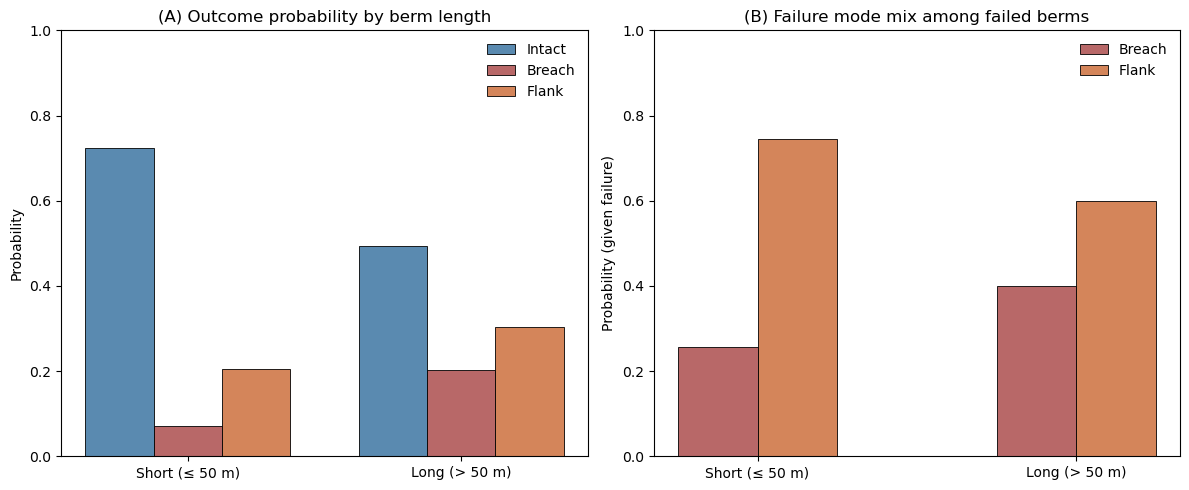

Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 5)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt
Saved: fig_length_fail_type.png


In [11]:
# ── Length × Fail_Type figure: two-panel barplot ──────────────────────────────
_fig_len, (_ax_a, _ax_b) = plt.subplots(1, 2, figsize=(12, 5))

# Panel A — unconditional outcome probabilities by length bin
_x_idx = np.arange(len(length_order))
_w = 0.25
for _i, _ft in enumerate(fail_order):
    _vals = [_prob.loc[_lb, f'P({_ft})'] for _lb in length_order]
    _bars = _ax_a.bar(_x_idx + _i * _w, _vals, _w, label=_ft,
                      color=fail_colors[_ft], edgecolor='black', linewidth=0.6)
_ax_a.set_xticks(_x_idx + _w)
_ax_a.set_xticklabels(length_order)
_ax_a.set_ylabel('Probability')
_ax_a.set_title('(A) Outcome probability by berm length')
_ax_a.legend(frameon=False)
_ax_a.set_ylim(0, 1)

# Panel B — failure mode mix among failed berms only
_cond_types = ['Breach', 'Flank']
for _i, _ft in enumerate(_cond_types):
    _vals = [_prob.loc[_lb, f'P({_ft}|failed)'] for _lb in length_order]
    _bars = _ax_b.bar(_x_idx + _i * _w, _vals, _w, label=_ft,
                      color=fail_colors[_ft], edgecolor='black', linewidth=0.6)
_ax_b.set_xticks(_x_idx + 0.5 * _w)
_ax_b.set_xticklabels(length_order)
_ax_b.set_ylabel('Probability (given failure)')
_ax_b.set_title('(B) Failure mode mix among failed berms')
_ax_b.legend(frameon=False)
_ax_b.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Save & register
_fname_len = 'fig_length_fail_type.png'
_fig_len.savefig(_os.path.join(_fig_dir, _fname_len), dpi=300, bbox_inches='tight')

register_failure_mechanisms_figure(
    'fig5', _fname_len,
    f'Length × failure type (threshold 50 m). χ² = {_chi2_len:.2f}, p = {_p_len:.3g}, '
    f"Cramér's V = {_V_len:.3f}. Fisher exact (breach vs flank × long vs short): "
    f'OR = {_or_bf:.2f}, p = {_p_bf:.3g}.',
    f'Two-panel view of how berm length relates to failure mode. '
    f'Panel A shows unconditional outcome probabilities; Panel B shows the '
    f'breach-vs-flank split among failed berms only.',
)
print(f'Saved: {_fname_len}')

## Slope × Fail_Type

Steeper slopes increase flow velocity and shear stress, potentially
influencing whether berms fail by breaching (overtopping) or flanking
(flow diversion around ends).

In [12]:
# ── Slope × Fail_Type: chi-square + pairwise (3-category) ────────────────────
_sub_sl = df.dropna(subset=['Slope_Class', 'Fail_Type']).copy()

_ct_sl = pd.crosstab(_sub_sl['Slope_Class'], _sub_sl['Fail_Type'])[fail_order]
print('─── counts ───')
print(_ct_sl)
print()

_pct_sl = _ct_sl.div(_ct_sl.sum(axis=1), axis=0).mul(100).round(1)
print('─── within-slope-class % ───')
print(_pct_sl)
print()

_chi2_sl, _p_sl, _dof_sl, _V_sl, _ = chi2_with_cramers_v(_ct_sl)
print(f'χ²({_dof_sl}) = {_chi2_sl:.2f},  p = {_p_sl:.3g},  Cramér\'s V = {_V_sl:.3f}')
print()

_pw_sl = _pairwise_chi2_3cat(_ct_sl)
_pw_sl_sig = _pw_sl[_pw_sl['significant']] if len(_pw_sl) else _pw_sl
print(f'Pairwise chi-square (FDR q < 0.05): {len(_pw_sl_sig)} significant')
if len(_pw_sl_sig):
    display(_pw_sl_sig.round(4).reset_index(drop=True))
else:
    print('  (none)')

─── counts ───
Fail_Type       Intact  Breach  Flank
Slope_Class                          
Shallow (≤ 2%)     243      63     78
Steep (> 2%)       215      51    125

─── within-slope-class % ───
Fail_Type       Intact  Breach  Flank
Slope_Class                          
Shallow (≤ 2%)    63.3    16.4   20.3
Steep (> 2%)      55.0    13.0   32.0

χ²(2) = 13.79,  p = 0.00101,  Cramér's V = 0.133

Pairwise chi-square (FDR q < 0.05): 1 significant


,group_a,group_b,chi2,dof,p_raw,q_fdr,significant
0,Shallow (≤ 2%),Steep (> 2%),13.7946,2,0.001,0.001,True


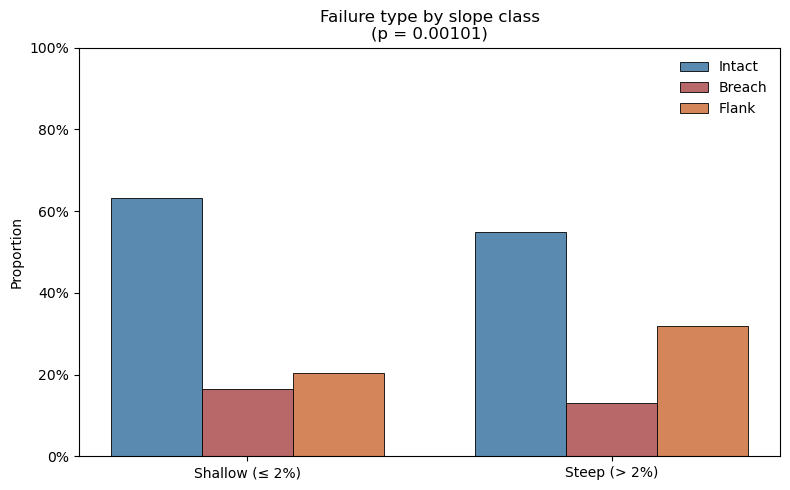

Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 6)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt
Saved: fig_slope_fail_type.png


In [13]:
# ── Slope × Fail_Type figure (3-category) ────────────────────────────────────
_fig_sl, _ax_sl = plt.subplots(figsize=(8, 5))
_plot_fail_bars(_ax_sl, _ct_sl, slope_order,
                title='Failure type by slope class',
                chi2_p=_p_sl)
plt.tight_layout()
plt.show()

_fname_sl = 'fig_slope_fail_type.png'
_fig_sl.savefig(_os.path.join(_fig_dir, _fname_sl), dpi=300, bbox_inches='tight')

register_failure_mechanisms_figure(
    'fig6', _fname_sl,
    f'Slope × failure type (Intact / Breach / Flank). '
    f'χ² = {_chi2_sl:.2f}, p = {_p_sl:.3g}, '
    f"Cramér's V = {_V_sl:.3f}. {len(_pw_sl_sig)} significant pairwise contrasts.",
    f'Failure mode breakdown by slope class. '
    f'Steeper slopes show higher flanking rate.',
)
print(f'Saved: {_fname_sl}')

## Soil Development × Fail_Type

Soils with a B horizon (Bt, Bk) indicate more developed pedogenic profiles,
often on older, more stable surfaces. Soil development may correlate with
surface cohesion and infiltration capacity, influencing failure mode.

In [14]:
# ── Soil Development × Fail_Type: chi-square + pairwise (3-category) ─────────
_sub_sd = df.dropna(subset=['Soil_Development', 'Fail_Type']).copy()

_ct_sd = pd.crosstab(_sub_sd['Soil_Development'], _sub_sd['Fail_Type'])[fail_order]
print('─── counts ───')
print(_ct_sd)
print()

_pct_sd = _ct_sd.div(_ct_sd.sum(axis=1), axis=0).mul(100).round(1)
print('─── within-soil-dev % ───')
print(_pct_sd)
print()

_chi2_sd, _p_sd, _dof_sd, _V_sd, _ = chi2_with_cramers_v(_ct_sd)
print(f'χ²({_dof_sd}) = {_chi2_sd:.2f},  p = {_p_sd:.3g},  Cramér\'s V = {_V_sd:.3f}')
print()

_pw_sd = _pairwise_chi2_3cat(_ct_sd)
_pw_sd_sig = _pw_sd[_pw_sd['significant']] if len(_pw_sd) else _pw_sd
print(f'Pairwise chi-square (FDR q < 0.05): {len(_pw_sd_sig)} significant')
if len(_pw_sd_sig):
    display(_pw_sd_sig.round(4).reset_index(drop=True))
else:
    print('  (none)')

─── counts ───
Fail_Type         Intact  Breach  Flank
Soil_Development                       
B horizon            158      34     97
No B horizon         300      80    106

─── within-soil-dev % ───
Fail_Type         Intact  Breach  Flank
Soil_Development                       
B horizon           54.7    11.8   33.6
No B horizon        61.7    16.5   21.8

χ²(2) = 13.80,  p = 0.00101,  Cramér's V = 0.133

Pairwise chi-square (FDR q < 0.05): 1 significant


,group_a,group_b,chi2,dof,p_raw,q_fdr,significant
0,B horizon,No B horizon,13.8023,2,0.001,0.001,True


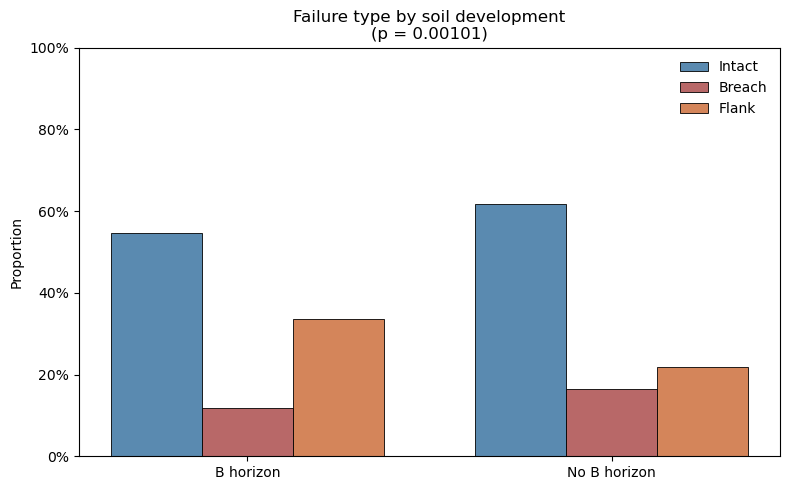

Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 7)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt
Saved: fig_soildev_fail_type.png


In [15]:
# ── Soil Development × Fail_Type figure (3-category) ─────────────────────────
_fig_sd, _ax_sd = plt.subplots(figsize=(8, 5))
_plot_fail_bars(_ax_sd, _ct_sd, soildev_order,
                title='Failure type by soil development',
                chi2_p=_p_sd)
plt.tight_layout()
plt.show()

_fname_sd = 'fig_soildev_fail_type.png'
_fig_sd.savefig(_os.path.join(_fig_dir, _fname_sd), dpi=300, bbox_inches='tight')

register_failure_mechanisms_figure(
    'fig7', _fname_sd,
    f'Soil development × failure type (Intact / Breach / Flank). '
    f'χ² = {_chi2_sd:.2f}, p = {_p_sd:.3g}, '
    f"Cramér's V = {_V_sd:.3f}. {len(_pw_sd_sig)} significant pairwise contrasts.",
    f'Failure mode breakdown by soil development. '
    f'B-horizon soils show higher flanking rate.',
)
print(f'Saved: {_fname_sd}')

## 100 % Stacked Bar — Fail_Type Composition by Landform

A proportional (100 %) stacked bar chart complements the grouped-bar view
by showing the *relative* composition of Intact / Breach / Flank within
each landform, making it easier to compare failure-mode ratios.

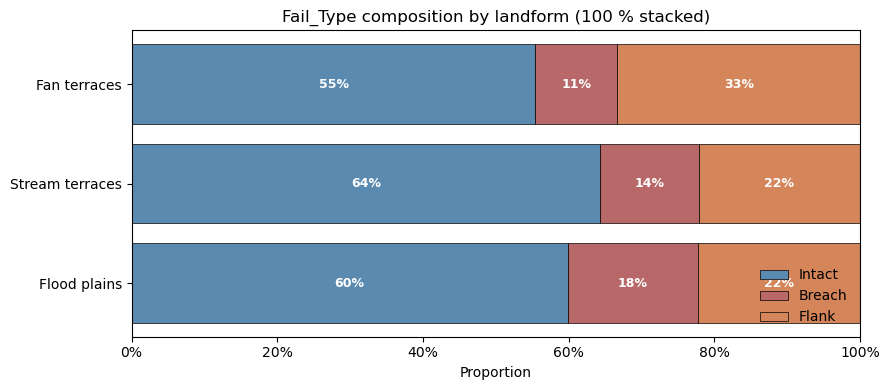

Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 8)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt
Saved: fig_stacked_fail_by_landform.png


In [16]:
# ── 100 % stacked horizontal bar chart: Fail_Type by Landform ─────────────────
_ct_stack = pd.crosstab(df['Landform'], df['Fail_Type'])[fail_order]
_props = _ct_stack.div(_ct_stack.sum(axis=1), axis=0)
_props = _props.loc[lf_order]

_fig_stk, _ax_stk = plt.subplots(figsize=(9, 4))
_y = np.arange(len(lf_order))
_left = np.zeros(len(lf_order))
for _ft in fail_order:
    _vals = _props[_ft].values
    _ax_stk.barh(_y, _vals, left=_left, color=fail_colors[_ft],
                 edgecolor='black', linewidth=0.5, label=_ft)
    # annotate percentage inside each segment
    for _j, (_v, _l) in enumerate(zip(_vals, _left)):
        if _v > 0.04:
            _ax_stk.text(_l + _v / 2, _j, f'{_v:.0%}', ha='center', va='center',
                         fontsize=9, fontweight='bold', color='white')
    _left += _vals

_ax_stk.set_yticks(_y)
_ax_stk.set_yticklabels(lf_order)
_ax_stk.set_xlabel('Proportion')
_ax_stk.set_title('Fail_Type composition by landform (100 % stacked)')
_ax_stk.legend(frameon=False, loc='lower right')
_ax_stk.set_xlim(0, 1)
_ax_stk.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
_ax_stk.invert_yaxis()
plt.tight_layout()
plt.show()

# Save & register
_fname_stk = 'fig_stacked_fail_by_landform.png'
_fig_stk.savefig(_os.path.join(_fig_dir, _fname_stk), dpi=300, bbox_inches='tight')

register_failure_mechanisms_figure(
    'fig8', _fname_stk,
    '100 % stacked bar chart showing relative Intact / Breach / Flank '
    'composition within each landform.',
    'Proportional failure-type composition by landform. '
    'Flood plains have the highest breach share; fan terraces the highest flank share.',
)
print(f'Saved: {_fname_stk}')

## Continuous Predictors × Fail_Type

The following sections analyse continuous site-level variables against the
three-level failure type using **Kruskal-Wallis** tests (non-parametric
one-way ANOVA) with **pairwise Mann-Whitney** post-hoc tests and
Benjamini–Hochberg FDR correction.

### Berm Angle (Directionality)

`berm_angle` measures the compass alignment of each berm relative to the
contour. The absolute value (`abs_angle`) captures how far from
perpendicular a berm is oriented, regardless of left/right direction.

In [17]:
# ── Berm angle (directionality) × Fail_Type ───────────────────────────────────
df['abs_angle'] = np.abs(df['berm_angle'])
print('=== Absolute berm angle × Fail_Type ===')
_res_angle = _continuous_by_failtype(df, 'abs_angle', label='|berm_angle|')

=== Absolute berm angle × Fail_Type ===
Kruskal-Wallis  H = 28.96,  p = 5.14e-07
  Group medians:
    Intact  : median = 36.673  (n = 458)
    Breach  : median = 26.187  (n = 114)
    Flank   : median = 57.380  (n = 203)

Pairwise Mann-Whitney (FDR q < 0.05):


,group_a,group_b,U,p_raw,q_fdr,significant
0,Intact,Breach,28829.0,0.0847,0.0,True
1,Breach,Flank,8036.0,0.0000,0.0,True


/var/folders/j3/k_zl73yn1mxfz7brb0f4_lx40000gn/T/ipykernel_17436/2735989324.py:108: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=df_sub, x='Fail_Type', y=col, order=fail_order,


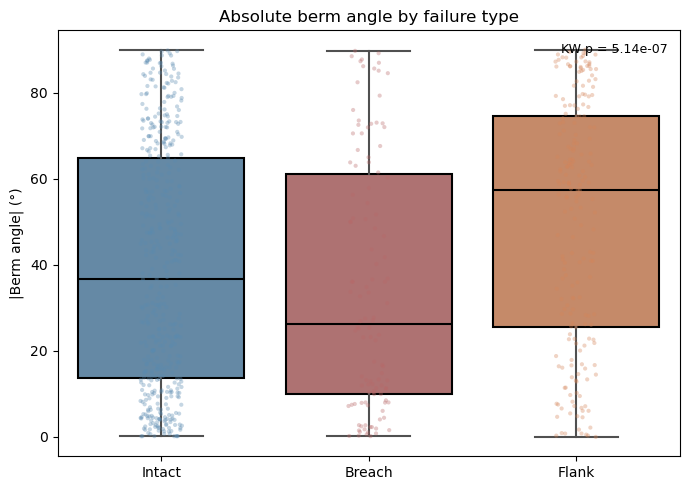

Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 9)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt
Saved: fig_angle_fail_type.png


In [18]:
# ── Berm angle × Fail_Type figure ─────────────────────────────────────────────
_fig_ang, _ax_ang = plt.subplots(figsize=(7, 5))
_plot_continuous_by_failtype(_ax_ang, df.dropna(subset=['abs_angle']),
                             'abs_angle',
                             title='Absolute berm angle by failure type',
                             ylabel='|Berm angle| (°)')
if _res_angle:
    _ax_ang.text(0.98, 0.97, f'KW p = {_res_angle["p_kw"]:.3g}',
                 transform=_ax_ang.transAxes, ha='right', va='top', fontsize=9)
plt.tight_layout()
plt.show()

_fname_ang = 'fig_angle_fail_type.png'
_fig_ang.savefig(_os.path.join(_fig_dir, _fname_ang), dpi=300, bbox_inches='tight')

_p_str = f'{_res_angle["p_kw"]:.3g}' if _res_angle else 'N/A'
register_failure_mechanisms_figure(
    'fig9', _fname_ang,
    f'Absolute berm angle by failure type. Kruskal-Wallis p = {_p_str}.',
    f'Box + strip plot of berm directionality by Fail_Type. '
    f'Tests whether berms farther from perpendicular are more prone to a specific failure mode.',
)
print(f'Saved: {_fname_ang}')

### Flow Accumulation

Upstream flow accumulation (`FA_30_mean`) measures the total contributing
drainage area reaching each berm (TauDEM, 30 m DEM). Higher values indicate
berms that intercept larger catchments and potentially greater runoff volume.
The variable is log-transformed (`log1p`) to address extreme right-skew
(range ~1 to >1 000 000).

In [19]:
# ── Flow accumulation × Fail_Type ─────────────────────────────────────────────
df['logFA'] = np.log1p(df['FA_30_mean'])
print('=== log(1 + FA_30_mean) × Fail_Type ===')
_res_fa = _continuous_by_failtype(df, 'logFA', label='log(FA_30_mean)')

=== log(1 + FA_30_mean) × Fail_Type ===
Kruskal-Wallis  H = 42.89,  p = 4.86e-10
  Group medians:
    Intact  : median = 4.781  (n = 458)
    Breach  : median = 6.213  (n = 114)
    Flank   : median = 5.881  (n = 203)

Pairwise Mann-Whitney (FDR q < 0.05):


,group_a,group_b,U,p_raw,q_fdr,significant
0,Intact,Breach,18817.0,0.0,0.0,True
1,Intact,Flank,33713.0,0.0,0.0,True


/var/folders/j3/k_zl73yn1mxfz7brb0f4_lx40000gn/T/ipykernel_17436/2735989324.py:108: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=df_sub, x='Fail_Type', y=col, order=fail_order,


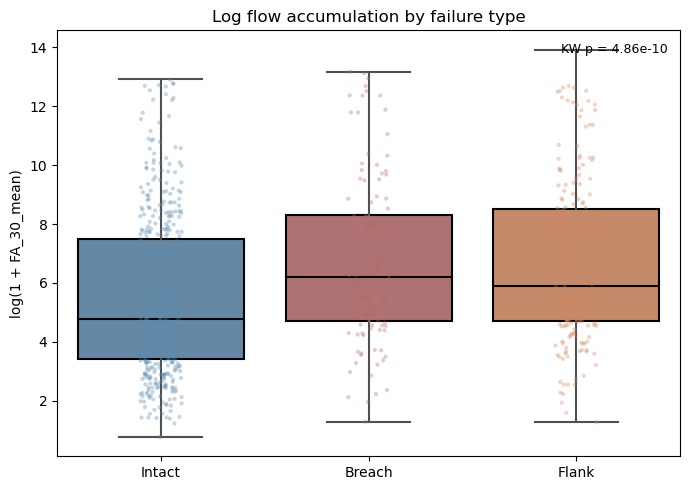

Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 10)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt
Saved: fig_flowaccum_fail_type.png


In [20]:
# ── Flow accumulation × Fail_Type figure ──────────────────────────────────────
_fig_fa, _ax_fa = plt.subplots(figsize=(7, 5))
_plot_continuous_by_failtype(_ax_fa, df.dropna(subset=['logFA']),
                             'logFA',
                             title='Log flow accumulation by failure type',
                             ylabel='log(1 + FA_30_mean)')
if _res_fa:
    _ax_fa.text(0.98, 0.97, f'KW p = {_res_fa["p_kw"]:.3g}',
                transform=_ax_fa.transAxes, ha='right', va='top', fontsize=9)
plt.tight_layout()
plt.show()

_fname_fa = 'fig_flowaccum_fail_type.png'
_fig_fa.savefig(_os.path.join(_fig_dir, _fname_fa), dpi=300, bbox_inches='tight')

_p_str = f'{_res_fa["p_kw"]:.3g}' if _res_fa else 'N/A'
register_failure_mechanisms_figure(
    'fig10', _fname_fa,
    f'Log flow accumulation by failure type. Kruskal-Wallis p = {_p_str}.',
    f'Box + strip plot of log-transformed upstream flow accumulation by Fail_Type. '
    f'Tests whether berms with larger contributing catchments are more prone to breach or flank.',
)
print(f'Saved: {_fname_fa}')

### SAVI Vegetation Indices

Soil-Adjusted Vegetation Index (SAVI) measured upstream (`saviU_60`) and
downstream (`saviD_60`) of each berm in a 60 m buffer, plus a reference
background (`savi_background`). The normalised vegetation effect
`(saviU − saviD) / savi_background` quantifies relative vegetation
response attributable to each berm.

In [21]:
# ── SAVI vegetation × Fail_Type ───────────────────────────────────────────────
print('=== Downstream SAVI (saviD_60) × Fail_Type ===')
_res_savi_d = _continuous_by_failtype(df, 'saviD_60', label='Downstream SAVI')

print('\n=== Upstream SAVI (saviU_60) × Fail_Type ===')
_res_savi_u = _continuous_by_failtype(df, 'saviU_60', label='Upstream SAVI')

# Vegetation effect (normalised)
if 'effect' not in df.columns:
    df['effect'] = (df['saviU_60'] - df['saviD_60']) / df['savi_background']
print('\n=== Vegetation effect × Fail_Type ===')
_res_veg_eff = _continuous_by_failtype(df, 'effect', label='Veg effect')

=== Downstream SAVI (saviD_60) × Fail_Type ===
Kruskal-Wallis  H = 1.95,  p = 0.377
  Group medians:
    Intact  : median = 0.147  (n = 458)
    Breach  : median = 0.143  (n = 114)
    Flank   : median = 0.143  (n = 203)

Pairwise Mann-Whitney (FDR q < 0.05):
  (none)

=== Upstream SAVI (saviU_60) × Fail_Type ===
Kruskal-Wallis  H = 0.27,  p = 0.876
  Group medians:
    Intact  : median = 0.158  (n = 458)
    Breach  : median = 0.155  (n = 114)
    Flank   : median = 0.159  (n = 203)

Pairwise Mann-Whitney (FDR q < 0.05):
  (none)

=== Vegetation effect × Fail_Type ===
Kruskal-Wallis  H = 0.19,  p = 0.911
  Group medians:
    Intact  : median = 0.058  (n = 458)
    Breach  : median = 0.070  (n = 114)
    Flank   : median = 0.059  (n = 203)

Pairwise Mann-Whitney (FDR q < 0.05):
  (none)


/var/folders/j3/k_zl73yn1mxfz7brb0f4_lx40000gn/T/ipykernel_17436/2735989324.py:108: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=df_sub, x='Fail_Type', y=col, order=fail_order,
/var/folders/j3/k_zl73yn1mxfz7brb0f4_lx40000gn/T/ipykernel_17436/2735989324.py:108: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=df_sub, x='Fail_Type', y=col, order=fail_order,
/var/folders/j3/k_zl73yn1mxfz7brb0f4_lx40000gn/T/ipykernel_17436/2735989324.py:108: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=df_sub, x='Fail_Type', y=col, order=fail_order,


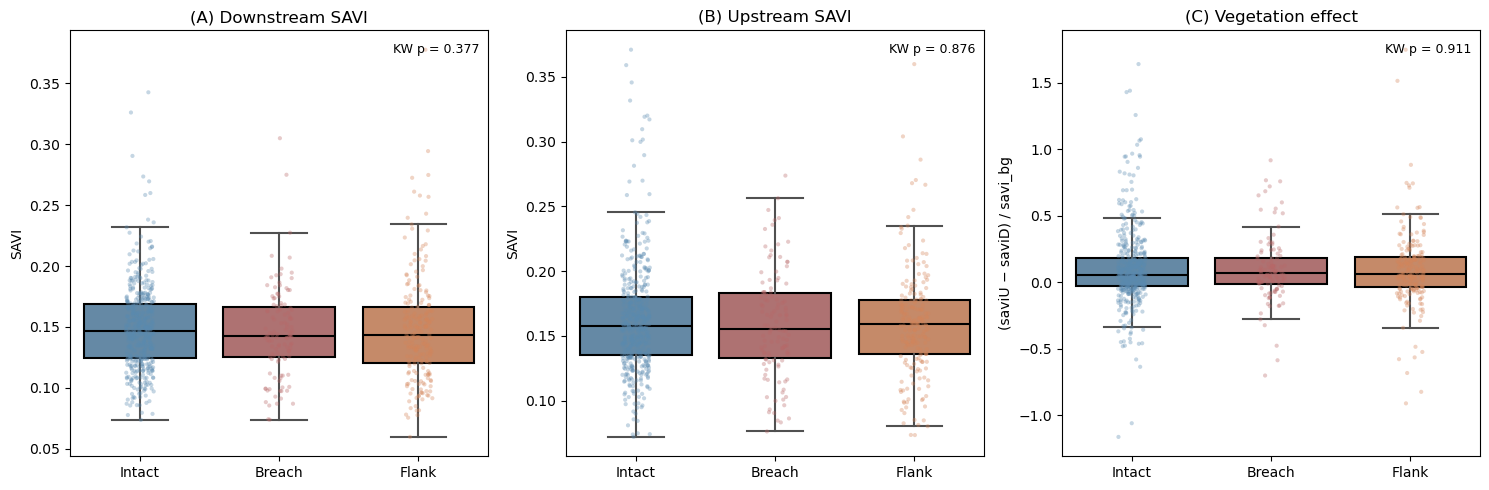

Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 11)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt
Saved: fig_savi_fail_type.png


In [22]:
# ── SAVI × Fail_Type figure (3-panel: downstream, upstream, veg effect) ──────
_fig_savi, (_ax_s1, _ax_s2, _ax_s3) = plt.subplots(1, 3, figsize=(15, 5))

_plot_continuous_by_failtype(_ax_s1, df.dropna(subset=['saviD_60']),
                             'saviD_60',
                             title='(A) Downstream SAVI',
                             ylabel='SAVI')
if _res_savi_d:
    _ax_s1.text(0.98, 0.97, f'KW p = {_res_savi_d["p_kw"]:.3g}',
                transform=_ax_s1.transAxes, ha='right', va='top', fontsize=9)

_plot_continuous_by_failtype(_ax_s2, df.dropna(subset=['saviU_60']),
                             'saviU_60',
                             title='(B) Upstream SAVI',
                             ylabel='SAVI')
if _res_savi_u:
    _ax_s2.text(0.98, 0.97, f'KW p = {_res_savi_u["p_kw"]:.3g}',
                transform=_ax_s2.transAxes, ha='right', va='top', fontsize=9)

_plot_continuous_by_failtype(_ax_s3, df.dropna(subset=['effect']),
                             'effect',
                             title='(C) Vegetation effect',
                             ylabel='(saviU − saviD) / savi_bg')
if _res_veg_eff:
    _ax_s3.text(0.98, 0.97, f'KW p = {_res_veg_eff["p_kw"]:.3g}',
                transform=_ax_s3.transAxes, ha='right', va='top', fontsize=9)

plt.tight_layout()
plt.show()

_fname_savi = 'fig_savi_fail_type.png'
_fig_savi.savefig(_os.path.join(_fig_dir, _fname_savi), dpi=300, bbox_inches='tight')

_p_d = f'{_res_savi_d["p_kw"]:.3g}' if _res_savi_d else 'N/A'
_p_u = f'{_res_savi_u["p_kw"]:.3g}' if _res_savi_u else 'N/A'
_p_e = f'{_res_veg_eff["p_kw"]:.3g}' if _res_veg_eff else 'N/A'
register_failure_mechanisms_figure(
    'fig11', _fname_savi,
    f'SAVI vegetation indices by failure type. KW p: downstream = {_p_d}, '
    f'upstream = {_p_u}, veg effect = {_p_e}.',
    f'Three-panel view of downstream SAVI, upstream SAVI, and normalised '
    f'vegetation effect by Fail_Type.',
)
print(f'Saved: {_fname_savi}')

### Road Distance

Distance to the nearest road (`road_dist`, metres). Roads may concentrate or
redirect flow, influencing whether adjacent berms fail by breaching or flanking.

In [23]:
# ── Road distance × Fail_Type ─────────────────────────────────────────────────
print('=== Road distance × Fail_Type ===')
_res_road = _continuous_by_failtype(df, 'road_dist', label='road_dist (m)')

=== Road distance × Fail_Type ===
Kruskal-Wallis  H = 9.42,  p = 0.00901
  Group medians:
    Intact  : median = 253.904  (n = 458)
    Breach  : median = 326.662  (n = 114)
    Flank   : median = 236.441  (n = 203)

Pairwise Mann-Whitney (FDR q < 0.05):


,group_a,group_b,U,p_raw,q_fdr,significant
0,Intact,Breach,21330.0,0.0025,0.0075,True
1,Breach,Flank,13568.0,0.0108,0.0162,True


/var/folders/j3/k_zl73yn1mxfz7brb0f4_lx40000gn/T/ipykernel_17436/2735989324.py:108: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=df_sub, x='Fail_Type', y=col, order=fail_order,


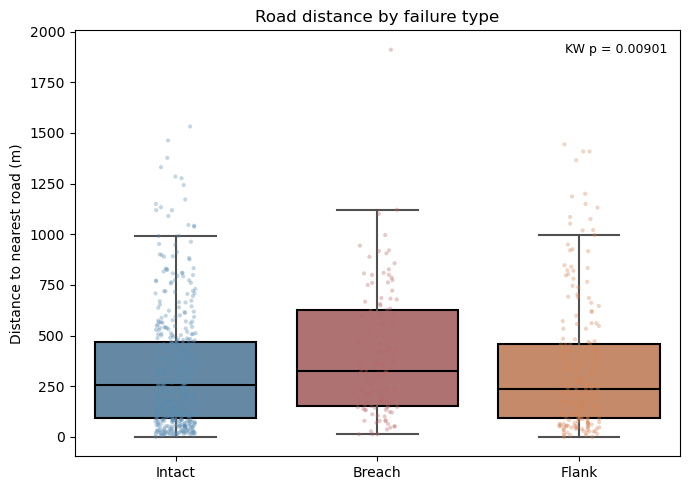

Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 12)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt
Saved: fig_roaddist_fail_type.png


In [24]:
# ── Road distance × Fail_Type figure ──────────────────────────────────────────
_fig_rd, _ax_rd = plt.subplots(figsize=(7, 5))
_plot_continuous_by_failtype(_ax_rd, df.dropna(subset=['road_dist']),
                             'road_dist',
                             title='Road distance by failure type',
                             ylabel='Distance to nearest road (m)')
if _res_road:
    _ax_rd.text(0.98, 0.97, f'KW p = {_res_road["p_kw"]:.3g}',
                transform=_ax_rd.transAxes, ha='right', va='top', fontsize=9)
plt.tight_layout()
plt.show()

_fname_rd = 'fig_roaddist_fail_type.png'
_fig_rd.savefig(_os.path.join(_fig_dir, _fname_rd), dpi=300, bbox_inches='tight')

_p_str = f'{_res_road["p_kw"]:.3g}' if _res_road else 'N/A'
register_failure_mechanisms_figure(
    'fig12', _fname_rd,
    f'Road distance by failure type. Kruskal-Wallis p = {_p_str}.',
    f'Box + strip plot of distance to nearest road by Fail_Type. '
    f'Tests whether road proximity influences failure mode.',
)
print(f'Saved: {_fname_rd}')

## High Clay × Fail_Type

`High_Clay` is a binary flag (True when clay content > median).
Higher clay content increases soil cohesion, which may resist end-scour
(flanking) but promote overtopping failures (breaching) when ponding
exceeds berm capacity.

In [25]:
# ── High Clay × Fail_Type: chi-square + pairwise ─────────────────────────────
_sub_hc = df.dropna(subset=['High_Clay', 'Fail_Type']).copy()
_sub_hc['Clay_Level'] = _sub_hc['High_Clay'].map({True: 'High Clay', False: 'Low Clay'})

_ct_hc = pd.crosstab(_sub_hc['Clay_Level'], _sub_hc['Fail_Type'])[fail_order]
print('─── counts ───')
display(_ct_hc)
print()

_pct_hc = (_ct_hc.div(_ct_hc.sum(axis=1), axis=0) * 100).round(1)
print('─── within-clay-level % ───')
display(_pct_hc)

_chi2_hc, _p_hc, _dof_hc, _V_hc, _ = chi2_with_cramers_v(_ct_hc)
print(f'\nχ²({_dof_hc}) = {_chi2_hc:.2f},  p = {_p_hc:.3g},  Cramér\'s V = {_V_hc:.3f}')

─── counts ───


Fail_Type,Intact,Breach,Flank
Clay_Level,,,
High Clay,223,57,64
Low Clay,235,57,139



─── within-clay-level % ───


Fail_Type,Intact,Breach,Flank
Clay_Level,,,
High Clay,64.8,16.6,18.6
Low Clay,54.5,13.2,32.3



χ²(2) = 18.49,  p = 9.66e-05,  Cramér's V = 0.154


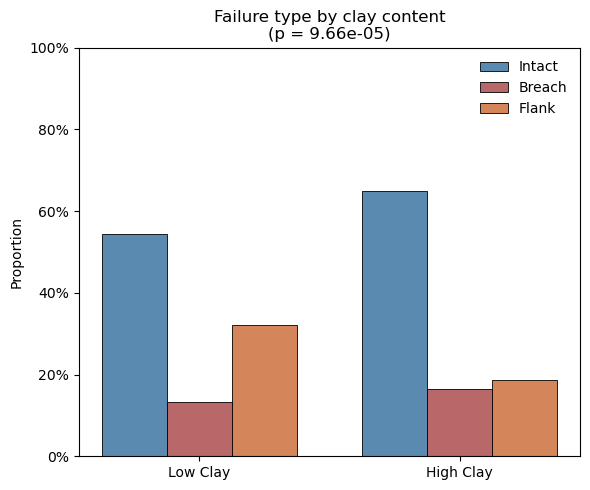

Updated → ../latex/figure_report_failure_mechanisms.tex  (Figure 13)
Updated: ../figures/failure_mechanisms/figure_registry.txt
Updated: ../figures/failure_mechanisms/figure_registry_concise.txt
Saved: fig_highclay_fail_type.png


In [26]:
# ── High Clay × Fail_Type figure ──────────────────────────────────────────────
_hc_order = ['Low Clay', 'High Clay']
_fig_hc, _ax_hc = plt.subplots(figsize=(6, 5))
_plot_fail_bars(_ax_hc, _ct_hc, _hc_order,
                title='Failure type by clay content',
                chi2_p=_p_hc)
plt.tight_layout()
plt.show()

_fname_hc = 'fig_highclay_fail_type.png'
_fig_hc.savefig(_os.path.join(_fig_dir, _fname_hc), dpi=300, bbox_inches='tight')

register_failure_mechanisms_figure(
    'fig13', _fname_hc,
    f'High vs Low clay × failure type. '
    f'χ² = {_chi2_hc:.2f}, p = {_p_hc:.3g}, '
    f"Cramér's V = {_V_hc:.3f}.",
    f'Failure mode breakdown by clay content. '
    f'Higher clay soils show relatively more breaching and less flanking.',
)
print(f'Saved: {_fname_hc}')

## Conditional Failure-Mode Probabilities

For each categorical predictor, compute:
- **P(Breach | failed)** and **P(Flank | failed)** per level — the share of
  failures that are breaches vs flanks.
- **Fisher exact odds ratio** (Breach vs Flank) comparing levels where sample
  size permits.

This extends the conditional approach used for `Berm_Length_Class` above to
all categorical predictors in a single summary table.

In [27]:
# ── Conditional P(Breach|failed), P(Flank|failed) for all categorical predictors
_cat_predictors = {
    'Texture':            [t for t in texture_order if t in _top3_tex],
    'Landform':           lf_order,
    'Berm_Length_Class':  length_order,
    'Slope_Class':        slope_order,
    'Soil_Development':   soildev_order,
}

_cond_rows = []
for _col, _levels in _cat_predictors.items():
    for _lv in _levels:
        _g = df.loc[(df[_col] == _lv) & (df['Fail_Type'] != 'Intact'), 'Fail_Type']
        _n_failed = len(_g)
        if _n_failed == 0:
            continue
        _n_breach = (_g == 'Breach').sum()
        _n_flank  = (_g == 'Flank').sum()
        _cond_rows.append({
            'Predictor': _col,
            'Level': _lv,
            'n_failed': _n_failed,
            'n_breach': _n_breach,
            'n_flank': _n_flank,
            'P(Breach|failed)': _n_breach / _n_failed,
            'P(Flank|failed)':  _n_flank  / _n_failed,
        })

_cond_df = pd.DataFrame(_cond_rows)
print('=== Conditional failure-mode probabilities ===')
display(_cond_df.round(3))

# ── Fisher exact OR for breach vs flank, comparing first and last level ──────
print('\n=== Fisher exact (Breach vs Flank) — first vs last level per predictor ===')
for _col, _levels in _cat_predictors.items():
    _sub = _cond_df.loc[_cond_df['Predictor'] == _col]
    if len(_sub) < 2:
        continue
    _first = _sub.iloc[0]
    _last  = _sub.iloc[-1]
    _table = np.array([
        [int(_first['n_breach']), int(_first['n_flank'])],
        [int(_last['n_breach']),  int(_last['n_flank'])],
    ])
    if _table.min() == 0:
        # add 0.5 continuity correction for zero cells
        _or_val, _p_val = fisher_exact(_table + 0.5)
    else:
        _or_val, _p_val = fisher_exact(_table)
    print(f'  {_col}: {_first["Level"]} vs {_last["Level"]}  →  '
          f'OR = {_or_val:.2f},  p = {_p_val:.3g}')

=== Conditional failure-mode probabilities ===


,Predictor,Level,n_failed,n_breach,n_flank,P(Breach|failed),P(Flank|failed)
0,Texture,Clay loam,108,53,55,0.491,0.509
1,Texture,Silt loam,49,19,30,0.388,0.612
2,Texture,Sandy loam,113,28,85,0.248,0.752
3,Landform,Fan terraces,123,31,92,0.252,0.748
4,Landform,Stream terraces,50,19,31,0.380,0.620
5,Landform,Flood plains,144,64,80,0.444,0.556
6,Berm_Length_Class,Short (≤ 50 m),90,23,67,0.256,0.744
7,Berm_Length_Class,Long (> 50 m),227,91,136,0.401,0.599
8,Slope_Class,Shallow (≤ 2%),141,63,78,0.447,0.553
9,Slope_Class,Steep (> 2%),176,51,125,0.290,0.710



=== Fisher exact (Breach vs Flank) — first vs last level per predictor ===
  Texture: Clay loam vs Sandy loam  →  OR = 2.93,  p = 0.00026
  Landform: Fan terraces vs Flood plains  →  OR = 0.42,  p = 0.00131
  Berm_Length_Class: Short (≤ 50 m) vs Long (> 50 m)  →  OR = 0.51,  p = 0.0192
  Slope_Class: Shallow (≤ 2%) vs Steep (> 2%)  →  OR = 1.98,  p = 0.00467
  Soil_Development: B horizon vs No B horizon  →  OR = 0.46,  p = 0.002


## Interaction Effects — Landform × Texture × Fail_Type

Do texture effects on failure mode differ across landforms? Within each
landform, we test whether the distribution of Fail_Type varies by texture
using Fisher exact tests (appropriate when expected counts are small in
stratified sub-tables).

In [28]:
# ── Within-landform Texture × Fail_Type stratified tests ──────────────────────
from scipy.stats import chi2_contingency as _chi2_contingency

_sub_int = df.loc[df['Texture'].isin(_top3_tex)].dropna(
    subset=['Landform', 'Texture', 'Fail_Type']).copy()

_int_rows = []
for _lf in lf_order:
    _lf_sub = _sub_int.loc[_sub_int['Landform'] == _lf]
    _ct_int = pd.crosstab(_lf_sub['Texture'], _lf_sub['Fail_Type'])
    # need at least 2 textures and 2 fail types present
    if _ct_int.shape[0] < 2 or _ct_int.shape[1] < 2:
        _int_rows.append({'Landform': _lf, 'n': len(_lf_sub),
                          'test': 'insufficient', 'p': float('nan')})
        continue
    # Use chi-square if expected counts ≥ 5, else Fisher (via simulate)
    _, _p_int, _, _exp = _chi2_contingency(_ct_int)
    if (_exp < 5).any():
        # Fisher–Freeman–Halton via chi-square with simulated p-value is not
        # available in scipy; fall back to chi-square but flag the issue.
        _method = 'chi2 (small expected)'
    else:
        _method = 'chi2'
    _int_rows.append({
        'Landform': _lf,
        'n': len(_lf_sub),
        'test': _method,
        'p': _p_int,
        'n_textures': _ct_int.shape[0],
        'n_fail_types': _ct_int.shape[1],
    })

_int_df = pd.DataFrame(_int_rows)
print('=== Within-landform Texture × Fail_Type tests ===')
display(_int_df.round(4))

_sig_int = _int_df.dropna(subset=['p'])
if len(_sig_int):
    _sig_int = _sig_int.copy()
    _sig_int['q_fdr'] = _bh_adjust(_sig_int['p'].values)
    _sig_int['significant'] = _sig_int['q_fdr'] < 0.05
    print('\nWith FDR correction:')
    display(_sig_int.round(4))

=== Within-landform Texture × Fail_Type tests ===


,Landform,n,test,p,n_textures,n_fail_types
0,Fan terraces,194,insufficient,NaN,NaN,NaN
1,Stream terraces,137,insufficient,NaN,NaN,NaN
2,Flood plains,299,chi2 (small expected),0.0121,2.0,3.0



With FDR correction:


,Landform,n,test,p,n_textures,n_fail_types,q_fdr,significant
2,Flood plains,299,chi2 (small expected),0.0121,2.0,3.0,0.0121,True


## SI Table Exports

Export summary tables for the failure mechanisms paper supplementary information.

In [29]:
# ── SI Table 1: Chi-square summary for categorical predictors ─────────────────
_si_dir = _os.path.join(_fig_dir, 'si_tables')
_os.makedirs(_si_dir, exist_ok=True)

_chi2_summary = pd.DataFrame([
    {'Predictor': 'Texture (top 3)',      'χ²': _chi2_tex, 'dof': _dof_tex, 'p': _p_tex, "Cramér's V": _V_tex},
    {'Predictor': 'Landform',             'χ²': _chi2_lf,  'dof': _dof_lf,  'p': _p_lf,  "Cramér's V": _V_lf},
    {'Predictor': 'Berm_Length_Class',    'χ²': _chi2_len, 'dof': _dof_len, 'p': _p_len, "Cramér's V": _V_len},
    {'Predictor': 'Slope_Class',          'χ²': _chi2_sl,  'dof': _dof_sl,  'p': _p_sl,  "Cramér's V": _V_sl},
    {'Predictor': 'Soil_Development',     'χ²': _chi2_sd,  'dof': _dof_sd,  'p': _p_sd,  "Cramér's V": _V_sd},
    {'Predictor': 'High_Clay',            'χ²': _chi2_hc,  'dof': _dof_hc,  'p': _p_hc,  "Cramér's V": _V_hc},
])
_chi2_summary.to_csv(_os.path.join(_si_dir, 'SI_chi2_summary_failtype.csv'), index=False)
print('SI Table 1 — Chi-square summary:')
display(_chi2_summary.round(4))

# ── SI Table 2: Conditional failure-mode probabilities ────────────────────────
_cond_df.to_csv(_os.path.join(_si_dir, 'SI_conditional_probs_failtype.csv'), index=False)
print('\nSI Table 2 — Conditional probabilities saved.')

# ── SI Table 3: Kruskal-Wallis summary for continuous predictors ──────────────
_kw_rows = []
for _name, _res in [('|berm_angle|', _res_angle), ('log(FA_30_mean)', _res_fa),
                     ('saviD_60', _res_savi_d), ('saviU_60', _res_savi_u),
                     ('veg_effect', _res_veg_eff), ('road_dist', _res_road)]:
    if _res is None:
        continue
    _kw_rows.append({'Predictor': _name, 'H': _res['H'], 'p': _res['p_kw']})
_kw_summary = pd.DataFrame(_kw_rows)
_kw_summary.to_csv(_os.path.join(_si_dir, 'SI_kruskal_wallis_failtype.csv'), index=False)
print('\nSI Table 3 — Kruskal-Wallis summary:')
display(_kw_summary.round(4))

# ── SI Table 4: Within-landform interaction tests ─────────────────────────────
if '_int_df' in dir():
    _int_df.to_csv(_os.path.join(_si_dir, 'SI_interaction_landform_texture.csv'), index=False)
    print('\nSI Table 4 — Interaction tests saved.')

print(f'\nAll SI tables saved to: {_si_dir}/')

SI Table 1 — Chi-square summary:


,Predictor,χ²,dof,p,Cramér's V
0,Texture (top 3),30.8160,4,0.0000,0.1564
1,Landform,14.4102,4,0.0061,0.0964
2,Berm_Length_Class,46.8233,2,0.0000,0.2458
3,Slope_Class,13.7946,2,0.0010,0.1334
4,Soil_Development,13.8023,2,0.0010,0.1335
5,High_Clay,18.4903,2,0.0001,0.1545



SI Table 2 — Conditional probabilities saved.

SI Table 3 — Kruskal-Wallis summary:


,Predictor,H,p
0,|berm_angle|,28.9616,0.0000
1,log(FA_30_mean),42.8916,0.0000
2,saviD_60,1.9504,0.3771
3,saviU_60,0.2653,0.8758
4,veg_effect,0.1862,0.9111
5,road_dist,9.4181,0.0090



SI Table 4 — Interaction tests saved.

All SI tables saved to: ../figures/failure_mechanisms/si_tables/
